In [170]:
import numpy as np
import cv2
from skimage.exposure import equalize_adapthist
from PIL import Image
from pathlib import Path

In [171]:
DATA_DIR = Path.cwd() / "data"
ORIGINAL_DIR = DATA_DIR / "original"
LABELS_DIR = DATA_DIR / "labels"

In [172]:
def list_image_pairs():
    originals = sorted(ORIGINAL_DIR.glob("*.ppm"))
    labels = sorted(LABELS_DIR.glob("*.vk.ppm"))
    pairs = []
    for orig in originals:
        lbl = LABELS_DIR / f"{orig.stem}.vk.ppm"
        if lbl.exists():
            pairs.append((orig, lbl))
    return pairs


pairs = list_image_pairs()
print(f"Found {len(pairs)} input-target pairs")
for inp, tgt in pairs[:3]:
    print(f"  {inp.name} -> {tgt.name}")

Found 20 input-target pairs
  im0001.ppm -> im0001.vk.ppm
  im0002.ppm -> im0002.vk.ppm
  im0003.ppm -> im0003.vk.ppm


In [173]:
def extract_rgb_channels(image_path: Path):
    img = np.array(Image.open(image_path))
    return img[:, :, 0], img[:, :, 1], img[:, :, 2]

In [174]:
def create_eye_mask(image_path: Path):
    img = cv2.imread(str(image_path))
    mask = np.zeros(img.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    h, w = img.shape[:2]
    margin = 5
    rect = (margin, margin, w - 2 * margin, h - 2 * margin)
    cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
    result = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 255, 0).astype(np.uint8)
    return result > 0

In [175]:
import matplotlib.pyplot as plt

def show_images(images, titles=None, cols = None, figsize_per_image=4, cmap="gray"):
    n = len(images)
    if cols is None:
        cols = n

    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_image, rows * figsize_per_image))
    axes = np.atleast_1d(axes).ravel()
    for i, src in enumerate(images):
        if isinstance(src, (str, Path)):
            img = np.array(Image.open(src))
        else:
            img = src
        axes[i].imshow(img, cmap=cmap)
        if titles and i < len(titles):
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    for j in range(n, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

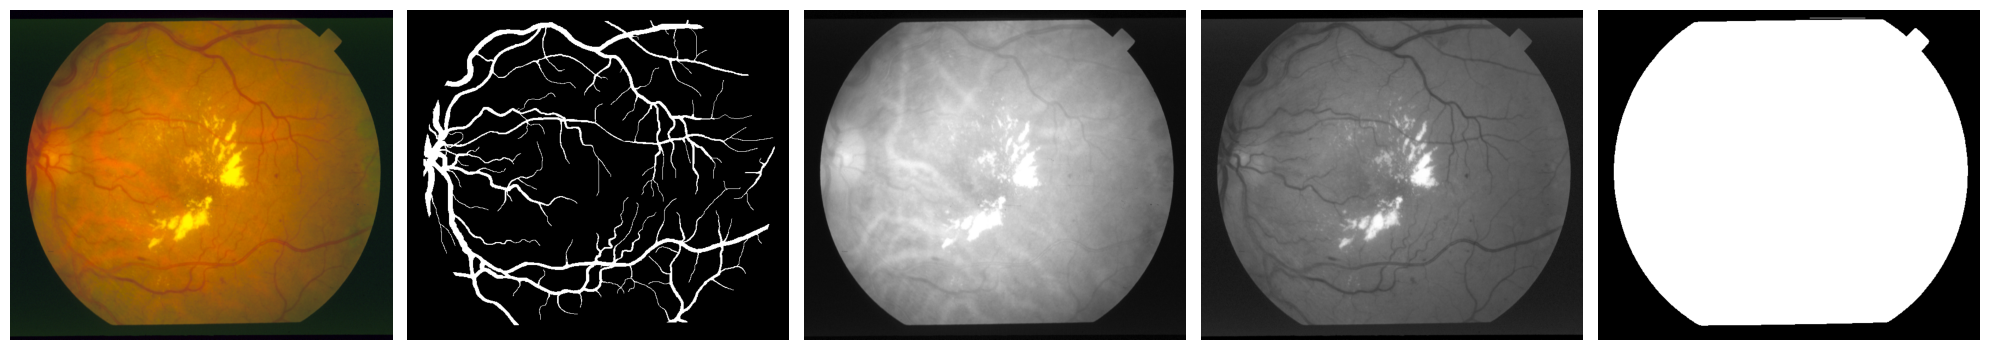

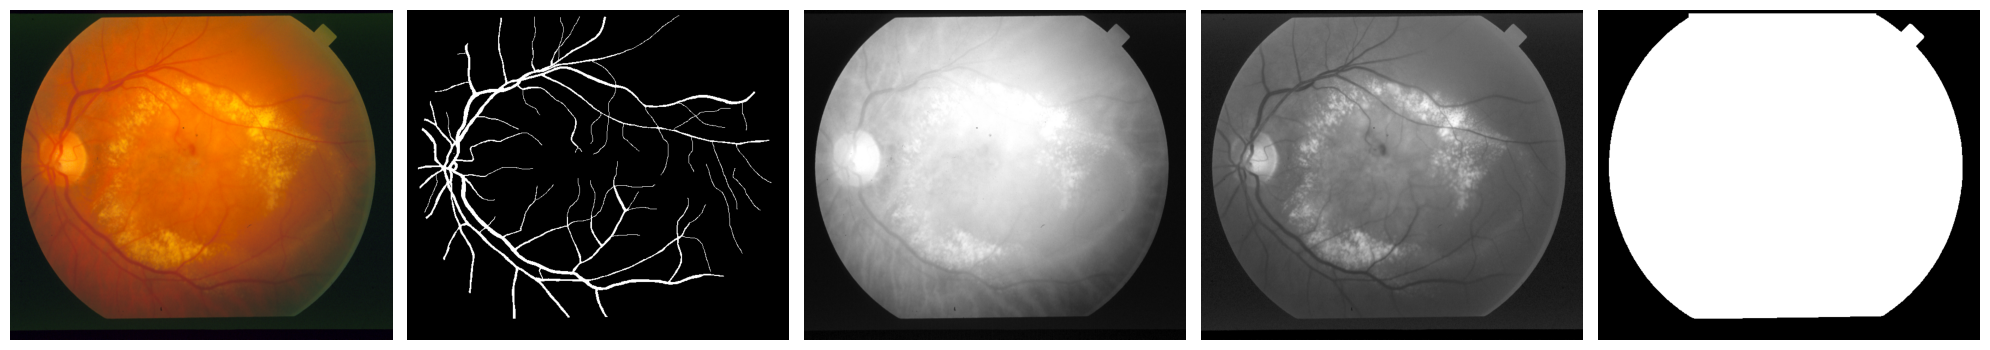

In [176]:
for orig, targ in pairs[:2]:
    r, g, b = extract_rgb_channels(orig)
    mask = create_eye_mask(orig)
    show_images([orig, targ, r, g, mask])

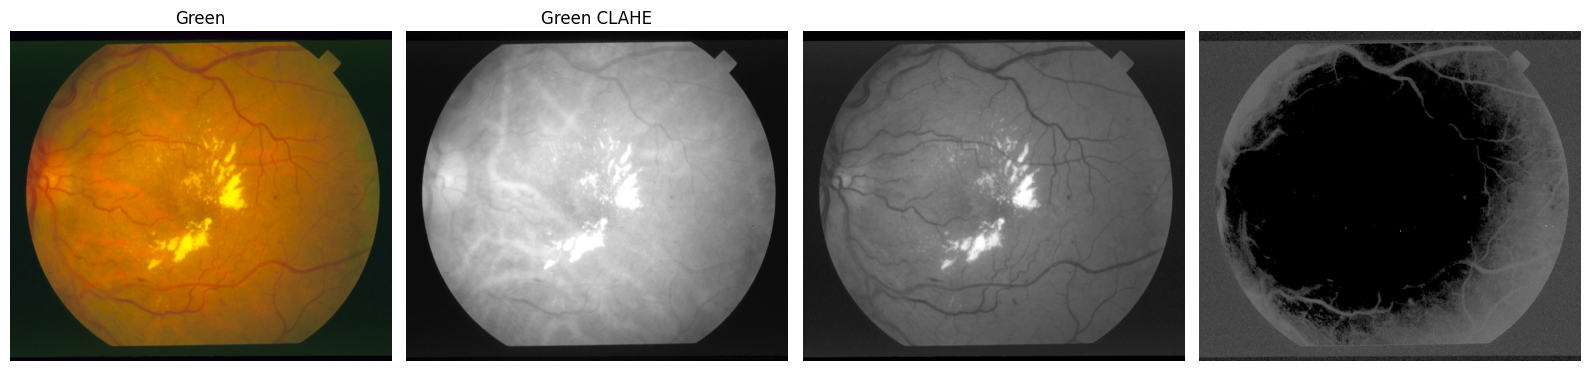

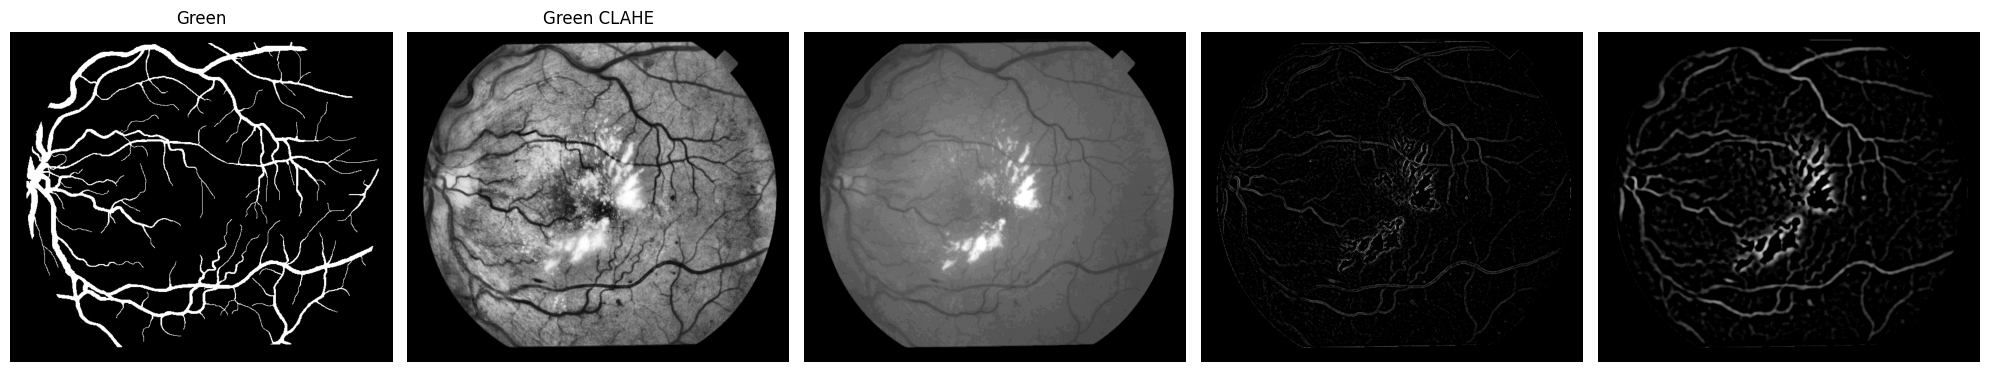

In [320]:
from skimage import exposure, morphology
from skimage.restoration import denoise_tv_chambolle


def apply_clahe(image, mask=None, clip_limit=0.03, nbins=256, kernel = None):
    if isinstance(image, (str, Path)):
        img = np.array(Image.open(image)).astype(float) / 255.0
    else:
        img = image.astype(float) / 255.0
    if mask is not None:
        img[~mask] = 0
    enhanced = equalize_adapthist(img, kernel_size=kernel, clip_limit=clip_limit, nbins=nbins)
    if mask is not None:
        enhanced[~mask] = 0
    return enhanced


def preprocess_image(image, mask, *, clip_limit = 0.02, nbins = 256, kernel = 100, gauss: tuple[int, int] = (13, 13)):
    if isinstance(image, (str, Path)):
        img = np.array(Image.open(image)).astype(np.uint8) / 255.0
    else:
        img = image.astype(np.uint8)

    img = cv2.bilateralFilter(img, 3, 75, 75)
    img = cv2.medianBlur(img, 5)


    bg_map = cv2.GaussianBlur(img, gauss, 1)
    flat_bg = cv2.subtract(bg_map, img)
    flat_bg = np.clip(flat_bg, 0, 255).astype(np.uint8)

    # kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    # flat_bg = cv2.morphologyEx(flat_bg, cv2.MORPH_OPEN, kernel)

    # flat_bg = cv2.medianBlur(flat_bg, 5)
    clahe = apply_clahe(flat_bg, mask=mask, clip_limit=clip_limit, nbins=nbins, kernel=kernel)
    eq = clahe
    # eq = exposure.adjust_gamma(clahe, gamma=0.4)

    return eq


def preprocess_image2(image, mask, *, clip_limit = 0.02, nbins = 256, kernel = 100, gauss: tuple[int, int] = (13, 13)):
    if isinstance(image, (str, Path)):
        img = np.array(Image.open(image)).astype(np.uint8) / 255.0
    else:
        img = image.astype(np.uint8)

    img = cv2.bilateralFilter(img, 9, 75, 75)
    # img = cv2.medianBlur(img, 3)


    bg_map = cv2.GaussianBlur(img, gauss, 0)
    flat_bg = cv2.subtract(bg_map, img)
    flat_bg = np.clip(flat_bg, 0, 255).astype(np.uint8)

    # kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, 1))
    # flat_bg = cv2.morphologyEx(flat_bg, cv2.MORPH_OPEN, kernel)

    clahe = apply_clahe(flat_bg, mask=mask, clip_limit=clip_limit, nbins=nbins, kernel=kernel)
    eq = clahe
    # eq = exposure.adjust_gamma(clahe, gamma=0.4)

    return eq

orig, targ = pairs[0]

mask = create_eye_mask(orig)
r, g, b = extract_rgb_channels(orig)

clahe = apply_clahe(g, mask, kernel=None)
clahe2 = apply_clahe(g, mask, kernel=100, clip_limit=0.01, nbins=25)
g_res = preprocess_image(g, mask, gauss=(11, 11), clip_limit=0.02, nbins=256)
g_res_v2 = preprocess_image2(g, mask, gauss=(31, 31))

show_images([orig, r, g, b], titles=['Green', 'Green CLAHE'], cmap='gray')
show_images([targ, clahe, clahe2, g_res, g_res_v2], titles=['Green', 'Green CLAHE'], cmap='gray')


In [ ]:
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler


def extract_patches(image, mask, patch_size, stride):
    half = patch_size // 2
    h, w = image.shape
    patches = []
    coords = []
    for y in range(half, h - half, stride):
        for x in range(half, w - half, stride):
            if not mask[y, x]:
                continue
            patch = image[y - half:y + half + 1, x - half:x + half + 1]
            patches.append(patch)
            coords.append((y, x))
    return patches, coords


def patch_features(patch):
    feats = []
    feats.append(float(np.mean(patch)))
    feats.append(float(np.std(patch)))
    feats.append(float(np.min(patch)))
    feats.append(float(np.max(patch)))
    for p in [5, 10, 25, 50, 75, 90, 95]:
        feats.append(float(np.percentile(patch, p)))
    gy, gx = np.gradient(patch.astype(float))
    gm = np.sqrt(gy ** 2 + gx ** 2)
    feats.append(float(np.mean(gm)))
    feats.append(float(np.std(gm)))
    return np.array(feats, dtype=np.float32)


def extract_and_process_patches(image, mask, gold_bin, patch_size, stride):
    half = patch_size // 2
    h, w = image.shape
    
    # 1. Generate the grid of coordinates based on stride
    y_indices = np.arange(half, h - half, stride)
    x_indices = np.arange(half, w - half, stride)
    yy, xx = np.meshgrid(y_indices, x_indices, indexing='ij')
    
    # 2. Filter coordinates using the mask
    mask_valid = mask[yy, xx]
    valid_y = yy[mask_valid]
    valid_x = xx[mask_valid]
    
    if len(valid_y) == 0:
        return np.empty((0, 13), dtype=np.float32), np.empty((0,), dtype=np.int32), (np.empty((0,), dtype=np.intp), np.empty((0,), dtype=np.intp))
    
    # 3. Vectorized patch extraction using stride_tricks
    shape = (h - patch_size + 1, w - patch_size + 1, patch_size, patch_size)
    strides = image.strides * 2
    all_patches = np.lib.stride_tricks.as_strided(image, shape=shape, strides=strides)
    
    # Map center coordinates (valid_y, valid_x) to top-left patch coordinates
    tl_y = valid_y - half
    tl_x = valid_x - half
    patches = all_patches[tl_y, tl_x]  # Shape: (N, patch_size, patch_size)
    
    # 4. Vectorized Feature Extraction
    N = patches.shape[0]
    # Flatten the spatial dimensions of the patches for easy axis-wise operations
    flat_patches = patches.reshape(N, -1)
    
    # Basic statistics
    # means = np.mean(flat_patches, axis=1)
    # stds = np.std(flat_patches, axis=1)
    # mins = np.min(flat_patches, axis=1)
    # maxs = np.max(flat_patches, axis=1)
    
    # # Percentiles
    # percentiles = np.percentile(flat_patches, [5, 10, 25, 50, 75, 90, 95], axis=1) # Shape: (7, N)
    
    # Gradients (computed simultaneously across all patches)
    # gy, gx = np.gradient(patches.astype(float), axis=(1, 2))
    # gm = np.sqrt(gy ** 2 + gx ** 2)
    # gm_flat = gm.reshape(N, -1)
    
    # gm_means = np.mean(gm_flat, axis=1)
    # gm_stds = np.std(gm_flat, axis=1)
    
    # 5. Assemble X_all and y_all
    X_all = np.column_stack([
        # means, stds, mins, maxs,
        # percentiles.T,
        # gm_means, gm_stds,
        flat_patches,
    ]).astype(np.float32)
    
    y_all = None
    if gold_bin is not None:
        y_all = gold_bin[valid_y, valid_x].astype(np.int32)
    
    return X_all, y_all, (valid_y, valid_x)



In [323]:
def build_training_dataset(pairs, patch_size=32, stride=16, clip_limit=0.03, nbins = 256, kernel = 100, gauss = (31, 31), verbose=True):
    X_result = []
    y_result = []
    coords_result = []
    for inp_path, lbl_path in pairs:
        gold_bin = None
        if lbl_path is not None:
            gold = np.array(Image.open(lbl_path))
            gold_bin = (gold > 0).astype(np.uint8)

        mask = create_eye_mask(inp_path)
        r, g, b = extract_rgb_channels(inp_path)
        # data = apply_clahe(g, mask=mask, clip_limit=0.02)
        data = preprocess_image(g, mask, clip_limit=clip_limit, nbins=nbins, kernel=kernel, gauss=gauss)
        data = (data * 255).astype(np.uint8)

        X_all, y_all, (yy, xx) = extract_and_process_patches(data, mask, gold_bin, patch_size, stride)
        X_result.extend(X_all)
        y_result.extend(y_all if y_all is not None else [])
        coords_result.extend((yy, xx))

        if verbose:
            n_vein = y_all.sum() if y_all is not None else 0
            print(f"{inp_path.stem}: {len(X_all)} patches, {n_vein} vein")

    return np.array(X_result, dtype=np.float32), np.array(y_result, dtype=np.int32), coords_result


# X, y = build_training_dataset(pairs[:1], patch_size=5, stride=1)
# print(X[:10])
# print(y[:10])
# print(f"\nTotal: X={X.shape}, y={y.shape}, veins={y.sum()}, BG={(y == 0).sum()}")


In [ ]:
# from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, balanced_accuracy_score, precision_score, recall_score


def make_balanced_pipeline(model=None):
    if model is None:
        model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
    return Pipeline([
        ('scaler', StandardScaler()),
        ('undersampler', RandomUnderSampler(random_state=42)),
        # ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('classifier', model),
    ])

im0001: 311788 patches, 39168 vein
im0002: 311358 patches, 23514 vein
im0003: 311700 patches, 24396 vein
im0004: 308122 patches, 30596 vein
im0005: 311902 patches, 44473 vein
Dataset: X=(1554870, 121), y=(1554870,)
Vein: 162147, BG: 1392723, Ratio: 0.116
train
Training set split Counter({np.int32(0): 129718, np.int32(1): 129718})

Accuracy:      0.8600
Sensitivity:   0.7871
Specificity:   0.8685
Mean(Se, Sp):  0.8278

Confusion Matrix:
  TN=241904  FP= 36641
  FN=  6905  TP= 25524


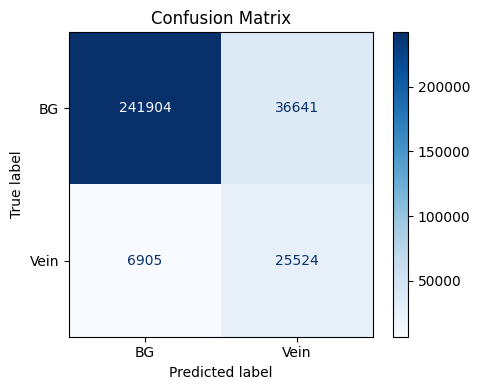

In [324]:
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

params = {"clip_limit": 0.01, "nbins": 256, "kernel": 100, "patch_size": 11, "gauss": (31, 31)}

X, y, _ = build_training_dataset(pairs[:5], **params, stride=1, verbose=True)
print(f'Dataset: X={X.shape}, y={y.shape}')
print(f'Vein: {y.sum()}, BG: {(y == 0).sum()}, Ratio: {y.sum() / max(1, (y == 0).sum()):.3f}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = make_balanced_pipeline()
print("train")
clf.fit(X_train, y_train)

undersampler = clf.named_steps["undersampler"]
indices = undersampler.sample_indices_
y_resampled = y_train[indices]
print("Training set split", Counter(y_resampled))
y_pred = clf.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / max(1, tp + fn)
specificity = tn / max(1, tn + fp)
balanced_acc = (sensitivity + specificity) / 2

print(f'\n{"="*40}')
print(f'Accuracy:      {accuracy:.4f}')
print(f'Sensitivity:   {sensitivity:.4f}')
print(f'Specificity:   {specificity:.4f}')
print(f'Mean(Se, Sp):  {balanced_acc:.4f}')
print(f'{"="*40}')
print(f'\nConfusion Matrix:')
print(f'  TN={tn:6d}  FP={fp:6d}')
print(f'  FN={fn:6d}  TP={tp:6d}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['BG', 'Vein'], cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()


training
im0235: 309183 patches, 0 vein
predicting
showing


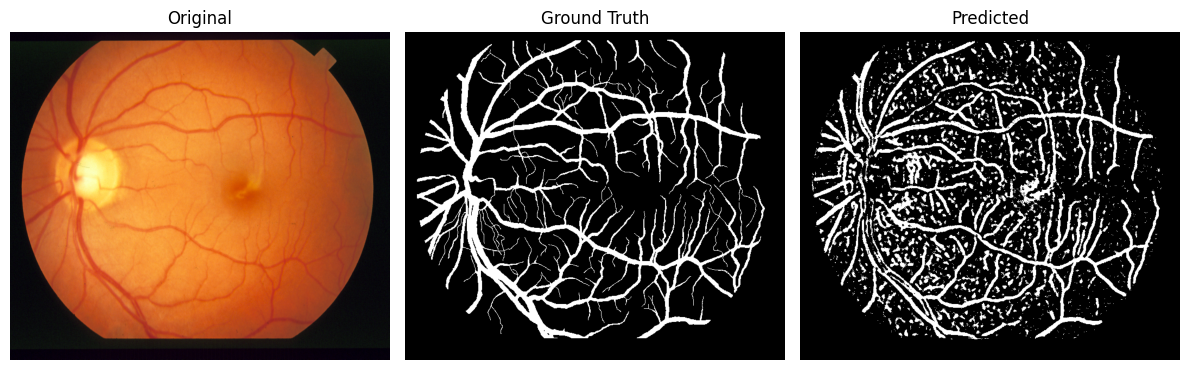

In [325]:
def predict_full_image(model, image_path, mask):
    img = np.array(Image.open(image_path))

    h, w, _ = img.shape
    pred_mask = np.zeros((h, w), dtype=np.uint8)

    # features, _, (yy, xx) = extract_and_process_patches(image_path, mask, **params, stride=1)
    print("training")
    features, _, (yy, xx) = build_training_dataset([(image_path, None)], **params, stride=1)

    print("predicting")
    # patches, coords = extract_patches(data, mask, patch_size, stride)
    # features = [patch_features(p) for p in patches]
    result = model.predict(features)

    pred_mask[yy, xx] = result

    print("showing")
    # for r, (yy, xx) in zip(result, coords):
    #     pred_mask[yy, xx] = r

        
    
    return pred_mask


# X, y = build_training_dataset(pairs[:8], patch_size=32, stride=16, verbose=False)
# clf = make_balanced_pipeline()
# clf.fit(X, y)

test_path = pairs[12][0]
test_label_path = pairs[12][1]
test_mask = create_eye_mask(test_path)
gold = (np.array(Image.open(test_label_path)) > 0).astype(np.uint8)

pred = predict_full_image(clf, test_path, mask)

show_images([test_path, gold, pred], titles=["Original", "Ground Truth", "Predicted"])